In [1]:
!pip install pandas matplotlib seaborn scikit-learn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
df = pd.read_csv('smmh.csv')

print("Number of rows and columns:", df.shape)
print("\nColumn names:")
for col in df.columns:
    print(" -", col)

df.head()

Number of rows and columns: (481, 21)

Column names:
 - Timestamp
 - 1. What is your age?
 - 2. Gender
 - 3. Relationship Status
 - 4. Occupation Status
 - 5. What type of organizations are you affiliated with?
 - 6. Do you use social media?
 - 7. What social media platforms do you commonly use?
 - 8. What is the average time you spend on social media every day?
 - 9. How often do you find yourself using Social media without a specific purpose?
 - 10. How often do you get distracted by Social media when you are busy doing something?
 - 11. Do you feel restless if you haven't used Social media in a while?
 - 12. On a scale of 1 to 5, how easily distracted are you?
 - 13. On a scale of 1 to 5, how much are you bothered by worries?
 - 14. Do you find it difficult to concentrate on things?
 - 15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?
 - 16. Following the previous question, how do you feel about these comparisons, ge

,Timestamp,1. What is your age?,2. Gender,3. Relationship Status,4. Occupation Status,5. What type of organizations are you affiliated with?,6. Do you use social media?,7. What social media platforms do you commonly use?,8. What is the average time you spend on social media every day?,9. How often do you find yourself using Social media without a specific purpose?,...,11. Do you feel restless if you haven't used Social media in a while?,"12. On a scale of 1 to 5, how easily distracted are you?","13. On a scale of 1 to 5, how much are you bothered by worries?",14. Do you find it difficult to concentrate on things?,"15. On a scale of 1-5, how often do you compare yourself to other successful people through the use of social media?","16. Following the previous question, how do you feel about these comparisons, generally speaking?",17. How often do you look to seek validation from features of social media?,18. How often do you feel depressed or down?,"19. On a scale of 1 to 5, how frequently does your interest in daily activities fluctuate?","20. On a scale of 1 to 5, how often do you face issues regarding sleep?"
0,4/18/2022 19:18:47,21.0,Male,In a relationship,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",Between 2 and 3 hours,5,...,2,5,2,5,2,3,2,5,4,5
1,4/18/2022 19:19:28,21.0,Female,Single,University Student,University,Yes,"Facebook, Twitter, Instagram, YouTube, Discord...",More than 5 hours,4,...,2,4,5,4,5,1,1,5,4,5
2,4/18/2022 19:25:59,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube, Pinterest",Between 3 and 4 hours,3,...,1,2,5,4,3,3,1,4,2,5
3,4/18/2022 19:29:43,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram",More than 5 hours,4,...,1,3,5,3,5,1,2,4,3,2
4,4/18/2022 19:33:31,21.0,Female,Single,University Student,University,Yes,"Facebook, Instagram, YouTube",Between 2 and 3 hours,3,...,4,4,5,5,3,3,3,4,4,1


In [3]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Drop rows with missing values
df = df.dropna()

# Clean up column names (remove spaces and special characters)
df.columns = [col.strip().replace(' ', '_').replace('?','').replace('.','').replace('/','_') for col in df.columns]

print("\nCleaned! Dataset size now:", df.shape)
print("\nNew column names:")
for col in df.columns:
    print(" -", col)

Missing values in each column:
Timestamp                                                                                                                0
1. What is your age?                                                                                                     0
2. Gender                                                                                                                0
3. Relationship Status                                                                                                   0
4. Occupation Status                                                                                                     0
5. What type of organizations are you affiliated with?                                                                  30
6. Do you use social media?                                                                                              0
7. What social media platforms do you commonly use?                                                         

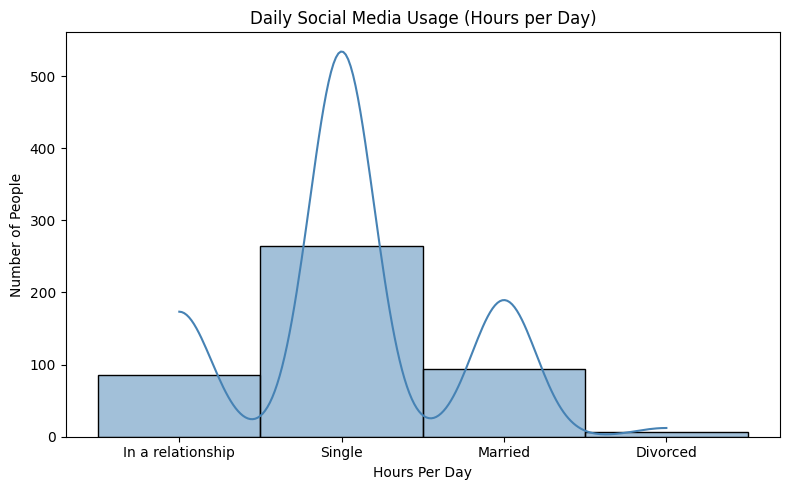

Chart 1 done!


In [4]:
plt.figure(figsize=(8,5))
usage_col = df.columns[3]
sns.histplot(df[usage_col], bins=20, color='steelblue', kde=True)
plt.title('Daily Social Media Usage (Hours per Day)')
plt.xlabel('Hours Per Day')
plt.ylabel('Number of People')
plt.tight_layout()
plt.savefig('chart1_usage.png', dpi=150)
plt.show()
print("Chart 1 done!")

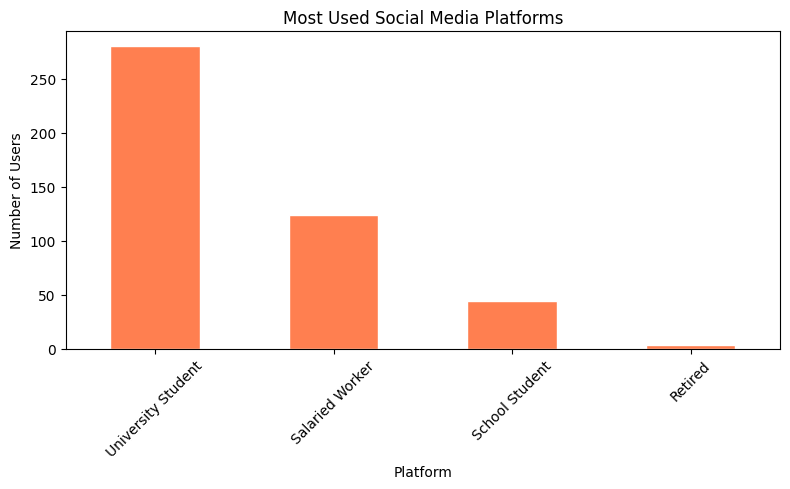

Chart 2 done!


In [5]:
plt.figure(figsize=(8,5))
platform_col = df.columns[4]
df[platform_col].value_counts().plot(kind='bar', color='coral', edgecolor='white')
plt.title('Most Used Social Media Platforms')
plt.xlabel('Platform')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart2_platforms.png', dpi=150)
plt.show()
print("Chart 2 done!")

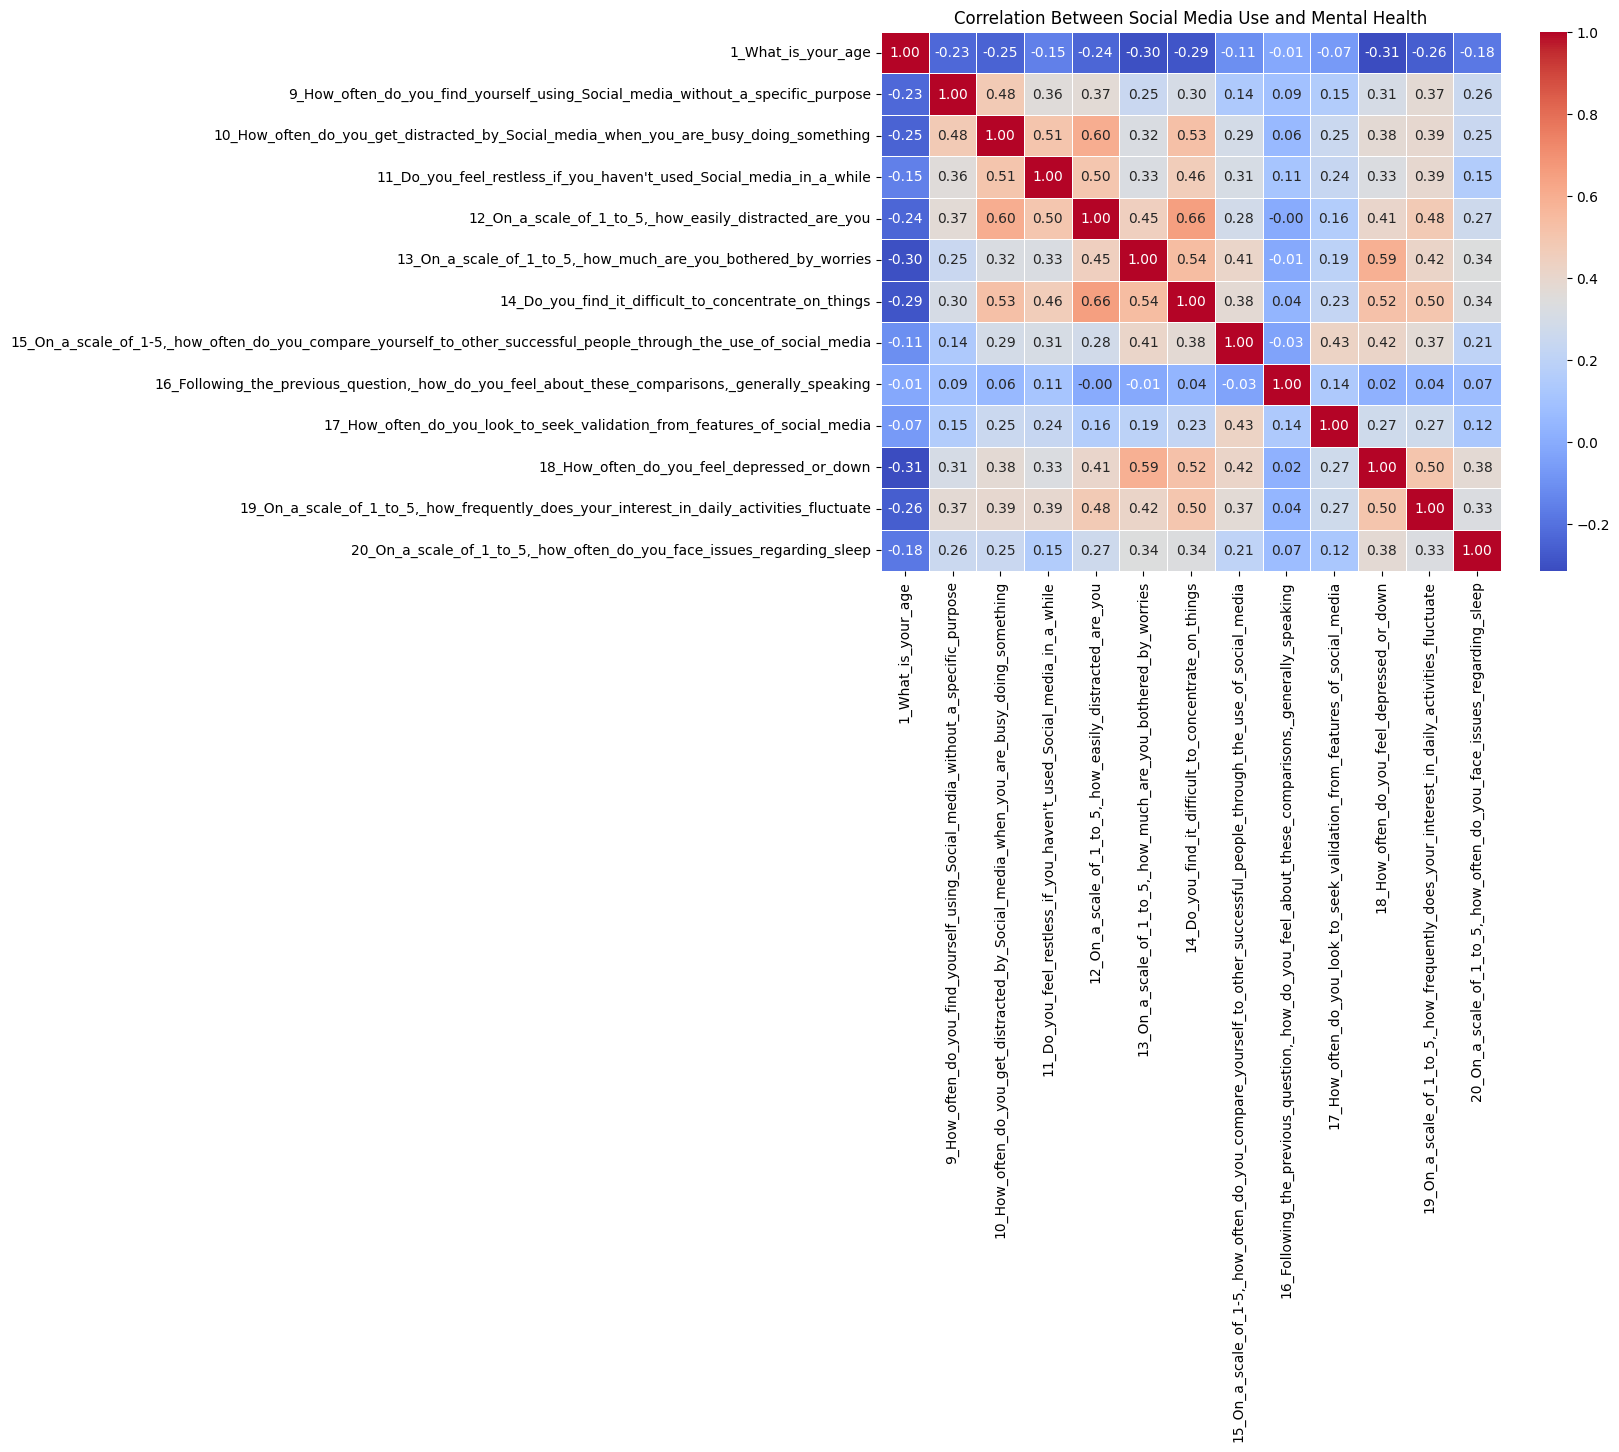

Chart 3 done!


In [6]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Social Media Use and Mental Health')
plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150)
plt.show()
print("Chart 3 done!")

In [7]:
usage_col = df.columns[3]
df['usage_group'] = pd.cut(df[usage_col],
                           bins=[0,2,4,6,24],
                           labels=['Low\n0-2h','Medium\n2-4h','High\n4-6h','Very High\n6h+'])

anxiety_col = numeric_df.columns[3]

plt.figure(figsize=(8,5))
colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
df.groupby('usage_group', observed=True)[anxiety_col].mean().plot(
    kind='bar', color=colors, edgecolor='white')
plt.title('Average Anxiety Score by Daily Social Media Usage')
plt.xlabel('Usage Group')
plt.ylabel('Average Anxiety Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart4_anxiety.png', dpi=150)
plt.show()
print("Chart 4 done!")

TypeError: '<' not supported between instances of 'int' and 'str'

In [8]:
print("All column names with their numbers:")
for i, col in enumerate(df.columns):
    print(f"{i} - {col}")

print("\nNumeric columns:")
for i, col in enumerate(numeric_df.columns):
    print(f"{i} - {col}")

All column names with their numbers:
0 - Timestamp
1 - 1_What_is_your_age
2 - 2_Gender
3 - 3_Relationship_Status
4 - 4_Occupation_Status
5 - 5_What_type_of_organizations_are_you_affiliated_with
6 - 6_Do_you_use_social_media
7 - 7_What_social_media_platforms_do_you_commonly_use
8 - 8_What_is_the_average_time_you_spend_on_social_media_every_day
9 - 9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose
10 - 10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something
11 - 11_Do_you_feel_restless_if_you_haven't_used_Social_media_in_a_while
12 - 12_On_a_scale_of_1_to_5,_how_easily_distracted_are_you
13 - 13_On_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries
14 - 14_Do_you_find_it_difficult_to_concentrate_on_things
15 - 15_On_a_scale_of_1-5,_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media
16 - 16_Following_the_previous_question,_how_do_you_feel_about_these_comparisons,_generally_speaking
17 

In [9]:
print("Shape:", df.shape)
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"{i} -- {col}")
```

---

**Then copy EVERYTHING that prints on screen and paste it here in this chat.**

It will look something like this:
```
0 -- age
1 -- gender
2 -- platform
3 -- hours per day
4 -- anxiety score
...

SyntaxError: invalid syntax (360146685.py, line 5)

In [10]:
# Check columns first
print("Columns:", df.columns.tolist())
print("Numeric columns:", numeric_df.columns.tolist())

Columns: ['Timestamp', '1_What_is_your_age', '2_Gender', '3_Relationship_Status', '4_Occupation_Status', '5_What_type_of_organizations_are_you_affiliated_with', '6_Do_you_use_social_media', '7_What_social_media_platforms_do_you_commonly_use', '8_What_is_the_average_time_you_spend_on_social_media_every_day', '9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose', '10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something', "11_Do_you_feel_restless_if_you_haven't_used_Social_media_in_a_while", '12_On_a_scale_of_1_to_5,_how_easily_distracted_are_you', '13_On_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries', '14_Do_you_find_it_difficult_to_concentrate_on_things', '15_On_a_scale_of_1-5,_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media', '16_Following_the_previous_question,_how_do_you_feel_about_these_comparisons,_generally_speaking', '17_How_often_do_you_look_to_seek_validation_from_feat

In [11]:
print("Shape:", df.shape)
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"{i} -- {col}")

Shape: (451, 21)

All columns:
0 -- Timestamp
1 -- 1_What_is_your_age
2 -- 2_Gender
3 -- 3_Relationship_Status
4 -- 4_Occupation_Status
5 -- 5_What_type_of_organizations_are_you_affiliated_with
6 -- 6_Do_you_use_social_media
7 -- 7_What_social_media_platforms_do_you_commonly_use
8 -- 8_What_is_the_average_time_you_spend_on_social_media_every_day
9 -- 9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose
10 -- 10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something
11 -- 11_Do_you_feel_restless_if_you_haven't_used_Social_media_in_a_while
12 -- 12_On_a_scale_of_1_to_5,_how_easily_distracted_are_you
13 -- 13_On_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries
14 -- 14_Do_you_find_it_difficult_to_concentrate_on_things
15 -- 15_On_a_scale_of_1-5,_how_often_do_you_compare_yourself_to_other_successful_people_through_the_use_of_social_media
16 -- 16_Following_the_previous_question,_how_do_you_feel_about_these_comparisons,_generally_s

In [12]:
# Using correct column names from your dataset
usage_col = '8_What_is_the_average_time_you_spend_on_social_media_every_day'
platform_col = '7_What_social_media_platforms_do_you_commonly_use'
anxiety_col = '13_On_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries'

# Show value counts for usage column
print("Usage values:")
print(df[usage_col].value_counts())

Usage values:
8_What_is_the_average_time_you_spend_on_social_media_every_day
More than 5 hours        111
Between 2 and 3 hours     93
Between 3 and 4 hours     86
Between 1 and 2 hours     65
Between 4 and 5 hours     63
Less than an Hour         33
Name: count, dtype: int64


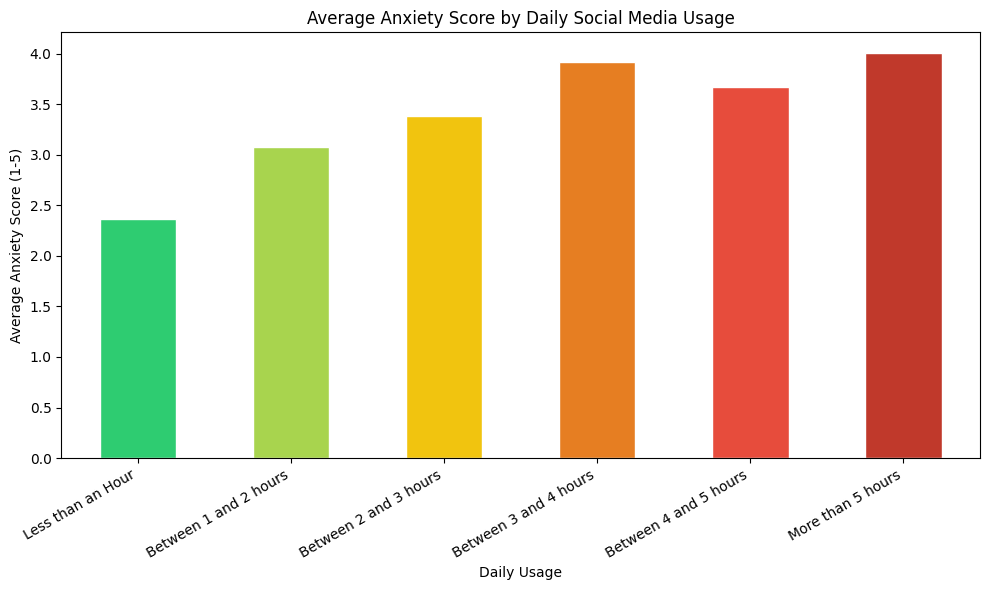

Chart 4 done!


In [13]:
# Correct column names
usage_col = '8_What_is_the_average_time_you_spend_on_social_media_every_day'
anxiety_col = '13_On_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries'

# Define correct order of usage groups
usage_order = [
    'Less than an Hour',
    'Between 1 and 2 hours',
    'Between 2 and 3 hours',
    'Between 3 and 4 hours',
    'Between 4 and 5 hours',
    'More than 5 hours'
]

# Calculate average anxiety for each group
anxiety_by_usage = df.groupby(usage_col)[anxiety_col].mean().reindex(usage_order)

# Plot the bar chart
plt.figure(figsize=(10,6))
colors = ['#2ecc71','#a8d44e','#f1c40f','#e67e22','#e74c3c','#c0392b']
anxiety_by_usage.plot(kind='bar', color=colors, edgecolor='white')
plt.title('Average Anxiety Score by Daily Social Media Usage')
plt.xlabel('Daily Usage')
plt.ylabel('Average Anxiety Score (1-5)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('chart4_anxiety.png', dpi=150)
plt.show()
print("Chart 4 done!")

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Define mental health risk using anxiety column
anxiety_col = '13_On_a_scale_of_1_to_5,_how_much_are_you_bothered_by_worries'
df['risk'] = (df[anxiety_col] >= df[anxiety_col].median()).astype(int)

# Encode all text columns into numbers
df_model = df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Features and target
numeric_df = df_model.select_dtypes(include='number')
X = numeric_df.drop(columns=['risk'])
y = df_model['risk']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Show results
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 100.00%

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00        52

    accuracy                           1.00        91
   macro avg       1.00      1.00      1.00        91
weighted avg       1.00      1.00      1.00        91



In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Define target: high risk based on DEPRESSION column (column 18)
depression_col = '18_How_often_do_you_feel_depressed_or_down'
df['risk'] = (df[depression_col] >= df[depression_col].median()).astype(int)

# Encode all text columns into numbers
df_model = df.copy()
le = LabelEncoder()
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Use ONLY social media behaviour columns as features
# NOT the mental health score columns
feature_cols = [
    '1_What_is_your_age',
    '8_What_is_the_average_time_you_spend_on_social_media_every_day',
    '9_How_often_do_you_find_yourself_using_Social_media_without_a_specific_purpose',
    '10_How_often_do_you_get_distracted_by_Social_media_when_you_are_busy_doing_something',
    '11_Do_you_feel_restless_if_you_haven\'t_used_Social_media_in_a_while',
    '12_On_a_scale_of_1_to_5,_how_easily_distracted_are_you',
    '17_How_often_do_you_look_to_seek_validation_from_features_of_social_media'
]

# Encode feature columns
df_model2 = df.copy()
le2 = LabelEncoder()
for col in df_model2.select_dtypes(include='object').columns:
    df_model2[col] = le2.fit_transform(df_model2[col].astype(str))

X = df_model2[feature_cols]
y = df['risk']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Show results
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 72.53%

Detailed Report:
              precision    recall  f1-score   support

           0       0.67      0.33      0.44        30
           1       0.74      0.92      0.82        61

    accuracy                           0.73        91
   macro avg       0.70      0.63      0.63        91
weighted avg       0.71      0.73      0.69        91



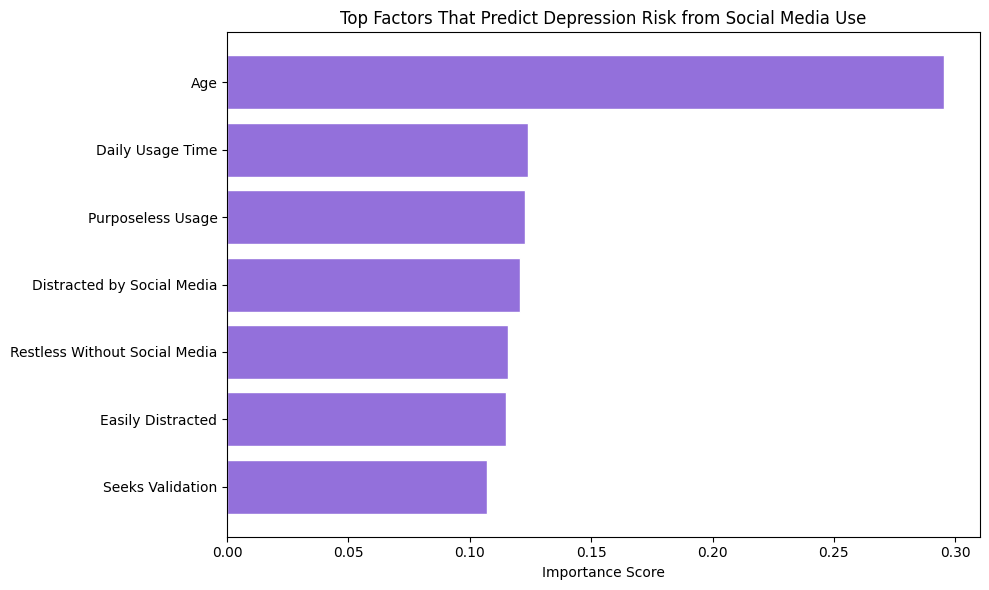

Chart 5 done!

Most important factor: Age


In [16]:
# Which social media habits predict depression the most?
feat_imp = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

# Clean up label names for the chart
clean_labels = [
    'Age',
    'Daily Usage Time',
    'Purposeless Usage',
    'Distracted by Social Media',
    'Restless Without Social Media',
    'Easily Distracted',
    'Seeks Validation'
]

plt.figure(figsize=(10,6))
bars = plt.barh(clean_labels, feat_imp.values, color='mediumpurple', edgecolor='white')
plt.title('Top Factors That Predict Depression Risk from Social Media Use')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('chart5_features.png', dpi=150)
plt.show()
print("Chart 5 done!")
print("\nMost important factor:", clean_labels[feat_imp.values.argmax()])

In [17]:
import os

files = ['chart1_usage.png', 'chart2_platforms.png',
         'chart3_heatmap.png', 'chart4_anxiety.png',
         'chart5_features.png']

print("Checking saved charts:")
for f in files:
    if os.path.exists(f):
        print(f"✓ {f} - SAVED")
    else:
        print(f"✗ {f} - NOT FOUND")

Checking saved charts:
✓ chart1_usage.png - SAVED
✓ chart2_platforms.png - SAVED
✓ chart3_heatmap.png - SAVED
✓ chart4_anxiety.png - SAVED
✓ chart5_features.png - SAVED


In [18]:
import zipfile
import os

# Put all charts into one zip file
with zipfile.ZipFile('all_charts.zip', 'w') as zipf:
    files = ['chart1_usage.png', 'chart2_platforms.png',
             'chart3_heatmap.png', 'chart4_anxiety.png',
             'chart5_features.png']
    for f in files:
        if os.path.exists(f):
            zipf.write(f)
            print(f"Added: {f}")
        else:
            print(f"Not found: {f}")

print("\nZip file created! Ready to download!")

Added: chart1_usage.png
Added: chart2_platforms.png
Added: chart3_heatmap.png
Added: chart4_anxiety.png
Added: chart5_features.png

Zip file created! Ready to download!
